In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

In [2]:
df_college = pd.read_csv("Data/CollegeBasketballPlayers2009-2021.csv")

df_college = df_college.drop(columns=["Unnamed: 64", "Unnamed: 65"], errors="ignore")

# We only Keep final college year for each player
df_college = df_college.sort_values(["player_name", "year"])
df_final = df_college.groupby("player_name").tail(1).copy()

# Make Target Variable
df_final["was_drafted"] = df_final["pick"].notna().astype(int)

print(df_final["was_drafted"].value_counts())


was_drafted
0    25098
1      621
Name: count, dtype: int64


/var/folders/2s/pmq2df492vgg1l49kmbj_zhr0000gn/T/ipykernel_10535/290325143.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df_college = pd.read_csv("Data/CollegeBasketballPlayers2009-2021.csv")


In [3]:
features = [
    "pts",      
    "ast",      
    "treb",     
    "TS_per",   
    "eFG",     
    "FT_per",   
    "FTA",      
    "TP_per",  
    "usg",      
    "Min_per",  
    "stl",      
    "blk",    
    "bpm",      
    "obpm",     
    "dbpm"      
]

In [4]:
df_model = df_final[features + ["was_drafted"]].dropna().copy()

X = df_model[features]
y = df_model["was_drafted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)




,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Accuracy: 0.9813265901575569
Random Forest AUC: 0.9707848154982736


In [7]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 497, number of negative: 20066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3816
[LightGBM] [Info] Number of data points in the train set: 20563, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.024170 -> initscore=-3.698192
[LightGBM] [Info] Start training from score -3.698192


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [8]:
lgb_pred = lgb.predict(X_test)
lgb_prob = lgb.predict_proba(X_test)[:, 1]

print("LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))
print("LightGBM AUC:", roc_auc_score(y_test, lgb_prob))

LightGBM Accuracy: 0.9791869286131103
LightGBM AUC: 0.9734467327216496


# Confusion Matrix Comparison

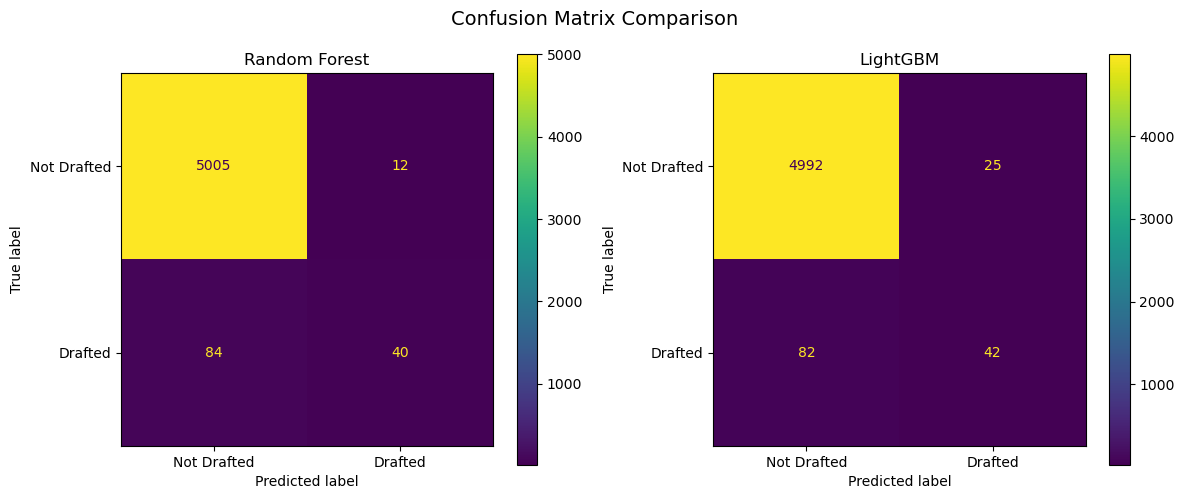

In [9]:
cm_rf = confusion_matrix(y_test, rf_pred)
cm_lgb = confusion_matrix(y_test, lgb_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Drafted", "Drafted"]
)
disp_rf.plot(ax=axes[0], values_format="d")
axes[0].set_title("Random Forest")

# LightGBM
disp_lgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgb,
    display_labels=["Not Drafted", "Drafted"]
)
disp_lgb.plot(ax=axes[1], values_format="d")
axes[1].set_title("LightGBM")

# 总标题
plt.suptitle("Confusion Matrix Comparison", fontsize=14)

plt.tight_layout()
plt.show()

# feature Importance Comparison

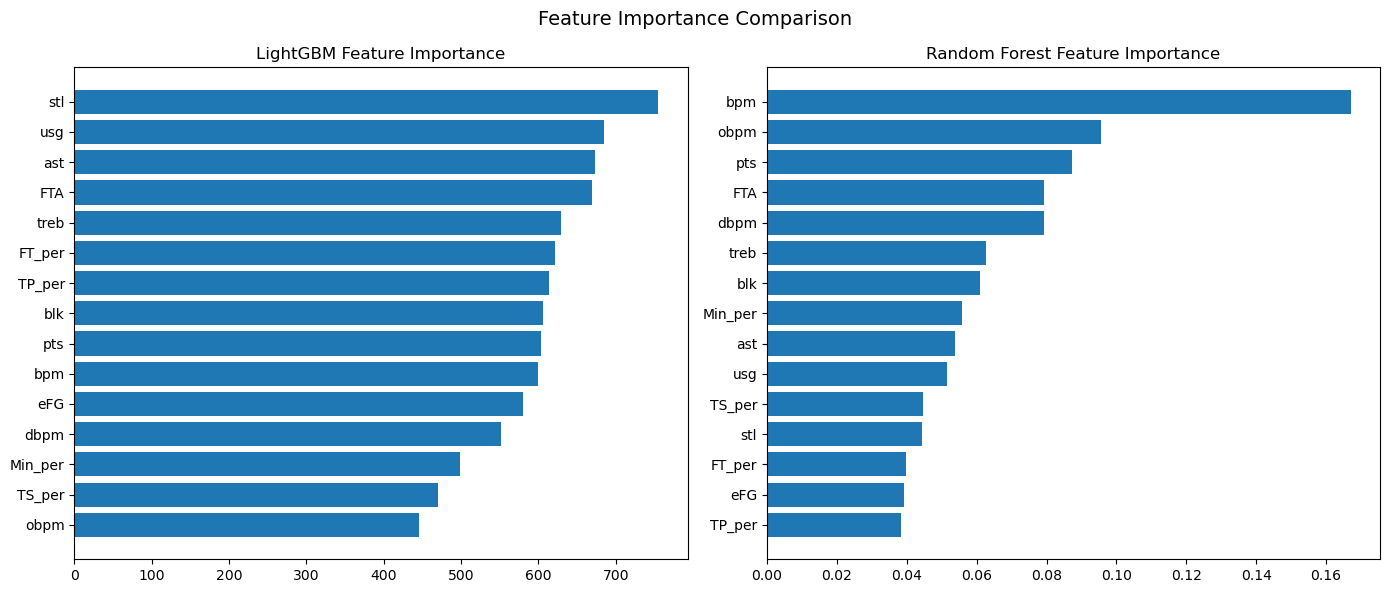

In [10]:
lgb_imp = pd.DataFrame({
    "feature": features,
    "importance": lgb.feature_importances_
}).sort_values("importance", ascending=False)


rf_imp = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(lgb_imp["feature"], lgb_imp["importance"])
axes[0].invert_yaxis()
axes[0].set_title("LightGBM Feature Importance")

# Random Forest
axes[1].barh(rf_imp["feature"], rf_imp["importance"])
axes[1].invert_yaxis()
axes[1].set_title("Random Forest Feature Importance")

plt.suptitle("Feature Importance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# Model Probability Distribution for Draft Prediction

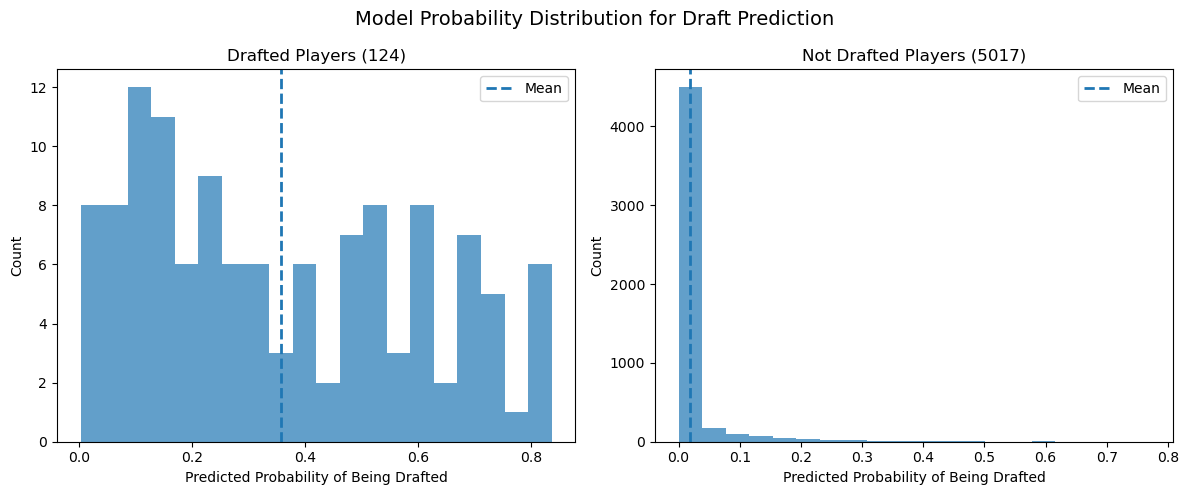

In [11]:
drafted_probs = rf_prob[y_test == 1]
not_drafted_probs = rf_prob[y_test == 0]

plt.figure(figsize=(12, 5))

# LEFT: drafted
plt.subplot(1, 2, 1)
plt.hist(drafted_probs, bins=20, alpha=0.7)
plt.axvline(drafted_probs.mean(), linestyle="--", linewidth=2, label="Mean")
plt.title(f"Drafted Players ({len(drafted_probs)})")
plt.xlabel("Predicted Probability of Being Drafted")
plt.ylabel("Count")
plt.legend()

# RIGHT: not drafted
plt.subplot(1, 2, 2)
plt.hist(not_drafted_probs, bins=20, alpha=0.7)
plt.axvline(not_drafted_probs.mean(), linestyle="--", linewidth=2, label="Mean")
plt.title(f"Not Drafted Players ({len(not_drafted_probs)})")
plt.xlabel("Predicted Probability of Being Drafted")
plt.ylabel("Count")
plt.legend()

plt.suptitle("Model Probability Distribution for Draft Prediction", fontsize=14)
plt.tight_layout()
plt.show()

# Predict draft pick position (1-60) (Regression)

In [12]:
df_range = df_final.dropna(subset=features + ["pick"]).copy()

bins = [0, 15, 30, 45, 60]
labels = ["1-15", "16-30", "31-45", "46-60"]

df_range["pick_range"] = pd.cut(
    df_range["pick"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


X_range = df_range[features]
y_range = df_range["pick_range"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_range,
    y_range,
    test_size=0.2,
    random_state=42,
    stratify=y_range
)

In [13]:
rf_cls = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_cls.fit(X_train_r, y_train_r)

pred = rf_cls.predict(X_test_r)

print("Accuracy:", accuracy_score(y_test_r, pred))
print(classification_report(y_test_r, pred))

Accuracy: 0.328
              precision    recall  f1-score   support

        1-15       0.38      0.55      0.44        33
       16-30       0.27      0.22      0.24        32
       31-45       0.19      0.13      0.15        31
       46-60       0.40      0.41      0.41        29

    accuracy                           0.33       125
   macro avg       0.31      0.33      0.31       125
weighted avg       0.31      0.33      0.31       125



In [ ]:
lgb_cls = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgb_cls.fit(X_train_r, y_train_r)

pred_lgb = lgb_cls.predict(X_test_r)

print("LightGBM Accuracy:", accuracy_score(y_test_r, pred_lgb))
print(classification_report(y_test_r, pred_lgb))

LightGBM Accuracy: 0.328
              precision    recall  f1-score   support

        1-15       0.41      0.52      0.46        33
       16-30       0.26      0.22      0.24        32
       31-45       0.26      0.26      0.26        31
       46-60       0.35      0.31      0.33        29

    accuracy                           0.33       125
   macro avg       0.32      0.33      0.32       125
weighted avg       0.32      0.33      0.32       125



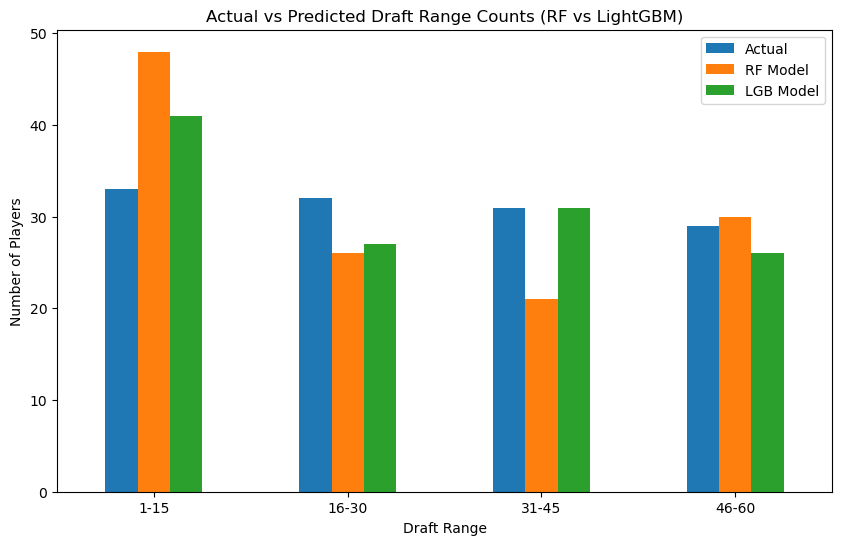

In [16]:
rf_df = pd.DataFrame({
    "Actual": y_test_r,
    "RF_Predicted": pred
})

# LGB
lgb_df = pd.DataFrame({
    "Actual": y_test_r,
    "LGB_Predicted": pred_lgb
})

# 统计 counts
actual_counts = y_test_r.value_counts().sort_index()
rf_counts = rf_df["RF_Predicted"].value_counts().sort_index()
lgb_counts = lgb_df["LGB_Predicted"].value_counts().sort_index()

# 合并
count_df = pd.DataFrame({
    "Actual": actual_counts,
    "RF Model": rf_counts,
    "LGB Model": lgb_counts
}).fillna(0)

count_df.plot(kind="bar", figsize=(10, 6))

plt.title("Actual vs Predicted Draft Range Counts (RF vs LightGBM)")
plt.xlabel("Draft Range")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)

plt.legend()
plt.show()

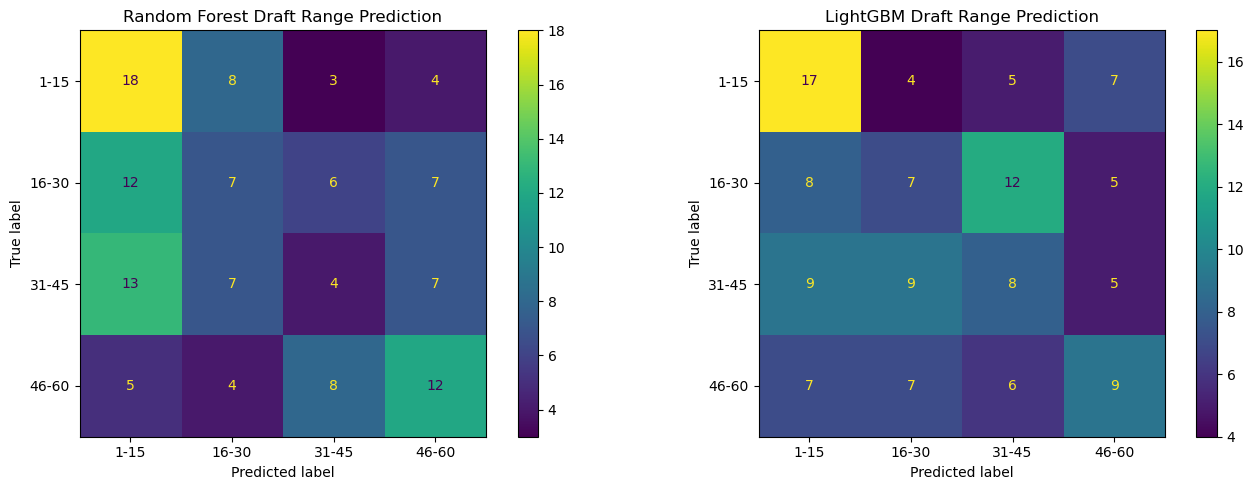

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    rf_cls,
    X_test_r,
    y_test_r,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Random Forest Draft Range Prediction")

ConfusionMatrixDisplay.from_estimator(
    lgb_cls,
    X_test_r,
    y_test_r,
    ax=axes[1],
    values_format="d"
)
axes[1].set_title("LightGBM Draft Range Prediction")

plt.tight_layout()
plt.show()

/var/folders/2s/pmq2df492vgg1l49kmbj_zhr0000gn/T/ipykernel_10535/2407309720.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = avg_prob.groupby("Actual")[classes].mean()


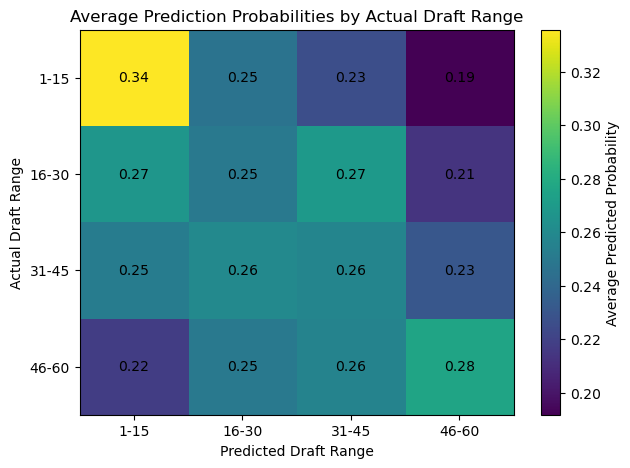

In [18]:
probs = rf_cls.predict_proba(X_test_r)
classes = rf_cls.classes_

avg_prob = pd.DataFrame(probs, columns=classes)
avg_prob["Actual"] = y_test_r.values

heatmap_data = avg_prob.groupby("Actual")[classes].mean()

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average Predicted Probability")
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("Predicted Draft Range")
plt.ylabel("Actual Draft Range")
plt.title("Average Prediction Probabilities by Actual Draft Range")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, round(heatmap_data.iloc[i, j], 2),
                 ha="center", va="center")

plt.show()